In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn import model_selection
from sklearn import preprocessing
from sklearn import linear_model
from sklearn import metrics

In [3]:
import joblib

In [4]:
from imblearn.over_sampling import SMOTE

# 1.Učitavanje i priprema podataka

In [5]:
data = pd.read_csv('../data/online_shoppers_intention.csv')

In [6]:
data.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [7]:
data.shape

(12330, 18)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [9]:
data = pd.get_dummies(data, columns=['Month', 'VisitorType'], drop_first=True)

In [10]:
data['Revenue'] = data['Revenue'].astype(int)
data['Weekend'] = data['Weekend'].astype(int)

In [11]:
x = data.drop(['Revenue'], axis=1)
y = data['Revenue']

In [12]:
x.shape

(12330, 26)

In [13]:
y.shape

(12330,)

Izvršena je podela ulaznih atributa na x i ciljnu promenljivu y koja predstavlja Revenue.

# 2. Podela podataka

U ovom koraku vrši se podela skupa podataka na skup za trening, validaciju i test. Trening skup se koristi za učenje modela, validacioni skup za podešavanje hiperparametara, a test skup za konačne performanse i evaluaciju modela.

In [14]:
x_train_validation, x_test, y_train_validation, y_test = model_selection.train_test_split(x,y, test_size=0.33, stratify=y, random_state=7)
x_train, x_validation, y_train, y_validation = model_selection.train_test_split(x_train_validation, y_train_validation, train_size=0.8, stratify=y_train_validation, random_state=7)

In [15]:
x_train.shape

(6608, 26)

In [16]:
x_test.shape

(4069, 26)

In [17]:
x_validation.shape

(1653, 26)

# 3. Standardizacija 

U ovom koraku podaci se standardizuju uz pomoć StandardScaler-a na osnovu parametara određenih iz trening skupa. Standardizacija se primenjuje na trening, test i validacioni skup.  

In [18]:
scaler = preprocessing.StandardScaler()

In [19]:
scaler.fit(x_train)

StandardScaler()

In [20]:
x_train = scaler.transform(x_train)
x_validation = scaler.transform(x_validation)
x_test= scaler.transform(x_test)

# 4. Podešavanje hiperparametra C i izbor modela Logističke regresije

In [21]:
Cs = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
best_score = 0
best_C = None

for C in Cs:
    model = linear_model.LogisticRegression(C=C, class_weight='balanced', random_state=7)
    model.fit(x_train, y_train)

    y_prob = model.predict_proba(x_validation)[:,1]
    score = metrics.roc_auc_score(y_validation, y_prob)

    if score > best_score:
        best_score = score
        best_C = C

print(f'Najbolji C {best_C}, a vrednost roc auc score-a je {best_score}')

Najbolji C 100, a vrednost roc auc score-a je 0.9040074713672155


Podešavanjem hiperparametara pronađena je najbolja kombinacija parametara: C = 100, sa ROC AUC skorom od 0.904 na validacionom skupu.

In [22]:
model = linear_model.LogisticRegression(C=best_C, class_weight='balanced', random_state=7)

In [23]:
x_train_validation_standardized = np.vstack([x_train, x_validation])

In [24]:
model.fit(x_train_validation_standardized, y_train_validation)

LogisticRegression(C=100, class_weight='balanced', random_state=7)

# 5. Analiza finalnog modela Logističke regresije

Nakon treniranja modela izvršena je evaluacija na test skup kako bi se procenila njegova uspešnost. Za procenu su koršćene metrike Accuracy, Precision, Recall, F1-score i ROC-AUC koje omogućavaju sagledavanje različitih aspekata kvaliteta predikcije modela.

In [25]:
model.intercept_

array([-0.00801243])

In [26]:
model.coef_

array([[ 0.00609269,  0.00772565,  0.07915456, -0.01843768,  0.00421071,
        -0.10673283, -0.06773391,  0.02908586,  0.02122471,  0.01249711,
         0.02895376, -0.01777679,  0.00583496, -0.0467905 ,  0.01770954,
        -0.00458717, -0.0111482 ,  0.02820448, -0.04233527,  0.00332384,
         0.01836802, -0.05037694, -0.0066258 ,  0.01091744, -0.00910608,
         0.03835834]])

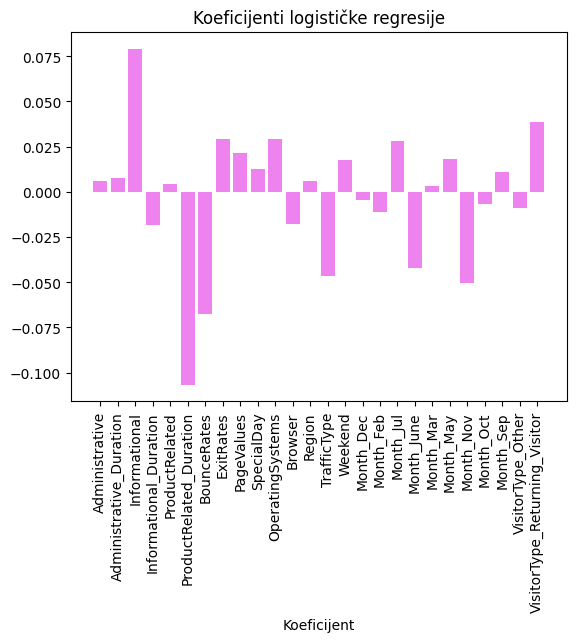

In [27]:
plt.bar(x.columns, model.coef_[0], color='violet')
plt.xlabel('Koeficijent')
plt.xticks(rotation='vertical')
plt.title('Koeficijenti logističke regresije')
plt.show()

Najjači pozitivan uticaj ima atribut Information, dok najjači negativan uticaj ima ProductRelated_Duration.

In [28]:
y_test_predicted = model.predict(x_test)

In [29]:
print(metrics.confusion_matrix(y_test, y_test_predicted))

[[1621 1818]
 [ 337  293]]


In [30]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.83      0.47      0.60      3439
           1       0.14      0.47      0.21       630

    accuracy                           0.47      4069
   macro avg       0.48      0.47      0.41      4069
weighted avg       0.72      0.47      0.54      4069



In [31]:
metrics.accuracy_score(y_test, y_test_predicted)

0.47038584418776114

In [32]:
metrics.precision_score(y_test, y_test_predicted)

0.13879677877783042

In [33]:
metrics.recall_score(y_test, y_test_predicted)

0.4650793650793651

In [34]:
metrics.f1_score(y_test, y_test_predicted)

0.21379058737686976

In [35]:
metrics.roc_auc_score(y_test, model.predict_proba(x_test)[:,1])

0.46617002912437633

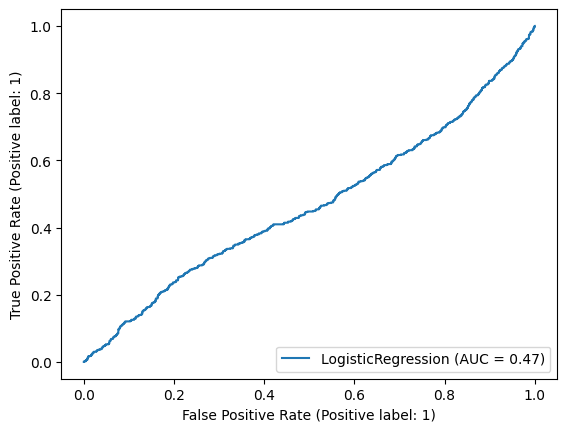

In [36]:
metrics.plot_roc_curve(model, x_test, y_test)

Na osnovu metrika može se zaključiti da model u ovom slučaju ne ostvaruje zadovoljavajuće rezultate. Ima veoma slabu sposobnost razlikovanja klasa na test skupu. 

# 6. Čuvanje dobijenog modela i scalera

In [37]:
joblib.dump(model, '../models/02-LogisticRegression01.pkl')
joblib.dump(scaler,'../models/02-Scaler.pkl')

['../models/02-Scaler.pkl']

# 7. Podešavanje hiperparametara i izbor optimalnog modela sa SMOTE metodom

S obzirom na izraženu neuravnoteženost ciljne promenljive, u nastavku je primenjena SMOTE metoda. Cilj ove metode je povećanje broja uzoraka manjinske klase generisanjem novih, sintetičkih primera na osnovu postojećih podataka. Na ovaj način se postiže uravnoteženija raspodela klasa, što može doprineti boljem prepoznavanju manjinske klase i poboljšanju performansi modela. 

In [38]:
print(y_train.value_counts())

0    5586
1    1022
Name: Revenue, dtype: int64


In [39]:
sampling_strategies= [1/5, 1/3, 1/2, 1]
Cs = [0.01, 0.1, 1, 10]

best_score = 0
best_sampling = None
best_C = None

for sampling_strategy in sampling_strategies:
    smote = SMOTE(k_neighbors=5, sampling_strategy=sampling_strategy, random_state=7)
    x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

    for C in Cs:
        model_smote = linear_model.LogisticRegression(C=C,random_state=7)
        model_smote.fit(x_train_resampled, y_train_resampled)

        y_prob = model_smote.predict_proba(x_validation)[:,1]
        score = metrics.roc_auc_score(y_validation, y_prob)

        if score > best_score:
            best_score = score
            best_sampling = sampling_strategy
            best_C = C 

In [40]:
print('Najbolji sampling_strategy: ', best_sampling)
print('Najbolji C: ',best_C )
print('Najbolji ROC AUC score: ', best_score)

Najbolji sampling_strategy:  1
Najbolji C:  10
Najbolji ROC AUC score:  0.9039347709377237


Podešavanjem hiperparametara pronađena je najbolja kombinacija parametara:
 sapling_strategy=1 i C =10, sa ROC AUC skorom od 0.90 na validacionom skupu. 

In [41]:
x_train_validation_standardized = np.vstack([x_train, x_validation])
y_train_validation = np.concatenate([y_train, y_validation])

In [42]:
smote_final = SMOTE(k_neighbors=5, sampling_strategy=best_sampling, random_state=7)

In [43]:
x_train_validation_resampled, y_train_validation_resampled = smote_final.fit_resample(x_train_validation_standardized, y_train_validation)

In [44]:
model_smote_final = linear_model.LogisticRegression(C=best_C, random_state=7)
model_smote_final.fit(x_train_validation_resampled, y_train_validation_resampled)

LogisticRegression(C=10, random_state=7)

In [45]:
y_test_predicted = model_smote_final.predict(x_test)

In [46]:
y_test_prob = model_smote_final.predict_proba(x_test)[:, 1]

In [47]:
print(y_train_resampled.value_counts())

0    5586
1    5586
Name: Revenue, dtype: int64


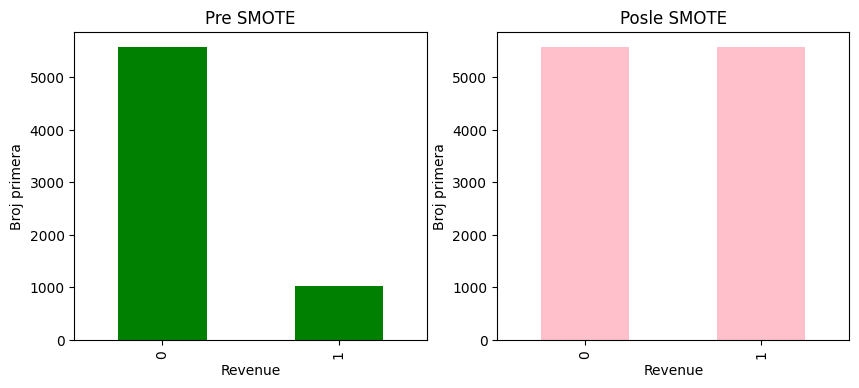

In [48]:
plt.figure(figsize=(10,4))

plt.subplot(121)
y_train.value_counts().sort_index().plot(kind='bar', color='green')
plt.title('Pre SMOTE')
plt.xlabel('Revenue')
plt.ylabel('Broj primera')
plt.xticks([0,1], ['0', '1'])

plt.subplot(122)
y_train_resampled.value_counts().sort_index().plot(kind='bar', color='pink')
plt.title('Posle SMOTE')
plt.xlabel('Revenue')
plt.ylabel('Broj primera')
plt.xticks([0,1], ['0', '1'])

plt.show()

Grafici prikazuju promenu odnosa klasa u trening skupu pre i nakon primene SMOTE algoritma sa izabranim parametrima sapling_strategy=1 i C =10. Hiperparametar sampling_strategy je doveo klasu 1 na isti broj primera kao klasa 0, odnosno sa 1022 na 5586, čime je postignuto potpuno balansiranje trening skupa.

# 8. Analiza finalnog SMOTE modela

In [49]:
print(metrics.confusion_matrix(y_test, y_test_predicted))

[[3023  416]
 [ 165  465]]


In [50]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91      3439
           1       0.53      0.74      0.62       630

    accuracy                           0.86      4069
   macro avg       0.74      0.81      0.76      4069
weighted avg       0.88      0.86      0.87      4069



In [51]:
metrics.accuracy_score(y_test, y_test_predicted)

0.8572130744654707

In [52]:
metrics.precision_score(y_test, y_test_predicted)

0.5278093076049943

In [53]:
metrics.recall_score(y_test, y_test_predicted)

0.7380952380952381

In [54]:
metrics.f1_score(y_test, y_test_predicted)

0.6154864328259431

In [55]:
metrics.roc_auc_score(y_test, model_smote_final.predict_proba(x_test)[:,1])

0.901572531697568

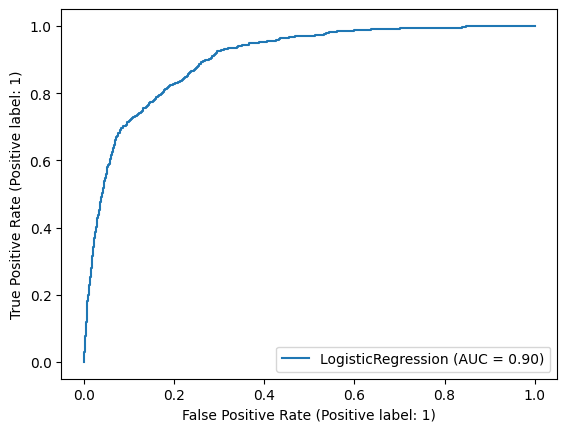

In [56]:
metrics.plot_roc_curve(model_smote_final, x_test, y_test)

Poređenjem rezultata, model sa SMOTE algoritmom pokazuje znatno bolje performanse od obične logističke regresije. Model bez SMOTE-a ima tačnost od svega 0,47 i ROC AUC od 0,47 što predstavlja rezultat lošiji od nasumičnog pogađanja. SMOTE model postiže tačnost od 0,86 i ROC AUC od 0,90 što pokazuje da model uspešno prepoznaje veliku većinu stvarnih kupovina, uz prihvatljiv broj lažno pozitivnih predikcija. 

Razlika je izražena i po ostalim metrikama: SMOTE  model ima znatno višu vrednost mera preciznost, recall i F1 score-a. Generisanje sintetičkih primera manjinske klase pomoću SMOTE-a je omogućilo modelu da mnogo bolje prepozna manjinsku klasu, odnosno kupovine, što potvrđuje da je SMOTE pristup značajno bolji u odnosu na standardnu logističku regresiju za ovaj problem. 

# 9. Čuvanje modela 

In [57]:
joblib.dump(model_smote_final, '../models/02-SMOTE.pkl')

['../models/02-SMOTE.pkl']

Model sa SMOTE algoritmom pokazuje znatno bolje i uravnoteženije performanse zato je on sačuvan kao bolji model.